# Тестовое задание Biocad

## Описание

Описание тестового задания:  
Реализовать простую модель машинного обучения, ĸоторая предсĸазывает знаĸ изменения свободной энергии связывания (ddG) на основе данных из базы SKEMPI 2.0. Необходимо продемонстрировать, что модель обучается (ĸачеством модели можно пренебречь в рамĸах тестового задания).  
Если не удаётся обучить модель или добиться ожидаемой обучаемости, просьба всё равно предоставить весь разработанный ĸод и описать проделанные шаги. Это
позволит нам оценить ваш подход ĸ решению задачи и уровень владения инструментами для работы с данными и моделями машинного обучения.
  
Требования ĸ выполненной работе:  
. Код должен быть загружен в виде репозитория на GitHub с публичным доступом.  
. Должны быть даны ĸомментарии ĸ ĸоду и описан ход ваших размышлений. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('skempi_v2.csv', delimiter=';')
display(df)

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,3QIB_ABP_CD,KP9R,KP8R,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,...,0.500,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7081,3QIB_ABP_CD,TP12A,TP11A,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SPR,2
7082,3QIB_ABP_CD,TP12S,TP11S,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,...,0.134,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7083,3QIB_ABP_CD,TP12N,TP11N,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",4.34E-05,4.340000e-05,5.5E-06,5.500000e-06,...,0.175,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2


Описание данных:  
База данных SKEMPI содержит информацию об изменениях термодинамических параметров и констант скорости реакций при мутациях для белок-белковых взаимодействий, структура которых была определена и доступна в базе данных белков.

Самое сложное в задании, это не обучить модель, а разобраться с данными и понять - а что тут собственно будет за целевая переменная и какие признаки использовать в качестве фичей. 

Проанализировав научные статьи ("MechPPI: Binding Mechanism-based Machine-Learning tool for Predicting Protein-Protein Binding Affinity Changes Upon Mutations" doi: https://doi.org/10.1101/2023.10.26.564257), я пришла в выводу, что надо самим рассчитать целевой признак (ddG), делается это по такой формуле:  $$ RT * ln(Kd_mut / Kd_wt) $$  где R - газовая постоянная, T - температура в Кельвинах.  

Подсказка по рассчету имеется на странице базы данных SKEMPI.
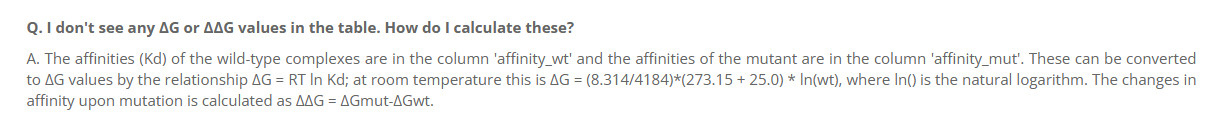  
Из статьи что выше: *Сила взаимодействия между белком и его партнером по связыванию — это сродство связывания, и это термодинамическое значение влияет на стабильность белковых комплексов. Константа равновесной диссоциации ( Kd ) или свободная энергия Гиббса (ΔG, также называемая свободной энергией связывания), которая может быть получена из Kd , может обычно использоваться для количественной оценки сродства связывания белок-белковых взаимодействий.*

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   #Pdb                          7085 non-null   object 
 1   Mutation(s)_PDB               7085 non-null   object 
 2   Mutation(s)_cleaned           7085 non-null   object 
 3   iMutation_Location(s)         7085 non-null   object 
 4   Hold_out_type                 3311 non-null   object 
 5   Hold_out_proteins             7085 non-null   object 
 6   Affinity_mut (M)              7085 non-null   object 
 7   Affinity_mut_parsed           6800 non-null   float64
 8   Affinity_wt (M)               7085 non-null   object 
 9   Affinity_wt_parsed            7083 non-null   float64
 10  Reference                     7085 non-null   object 
 11  Protein 1                     7085 non-null   object 
 12  Protein 2                     7085 non-null   object 
 13  Tem

df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce').astype('Int64')

In [4]:
df['Temperature'].unique()

array(['294', '298(assumed)', '298', '293', '295', '305', '310', '323',
       '273', '299', '296', '303', '300', '277', '283', '308', '333',
       '291', '279', '301', '281', '288', '285', nan, '338', '318'],
      dtype=object)

In [5]:
df['Temperature'] = df['Temperature'].str.extract('(\d+)').astype(float)

In [6]:
df['Temperature'].unique()

array([294., 298., 293., 295., 305., 310., 323., 273., 299., 296., 303.,
       300., 277., 283., 308., 333., 291., 279., 301., 281., 288., 285.,
        nan, 338., 318.])

In [7]:
df.isna().sum()

#Pdb                               0
Mutation(s)_PDB                    0
Mutation(s)_cleaned                0
iMutation_Location(s)              0
Hold_out_type                   3774
Hold_out_proteins                  0
Affinity_mut (M)                   0
Affinity_mut_parsed              285
Affinity_wt (M)                    0
Affinity_wt_parsed                 2
Reference                          0
Protein 1                          0
Protein 2                          0
Temperature                        4
kon_mut (M^(-1)s^(-1))          5241
kon_mut_parsed                  5241
kon_wt (M^(-1)s^(-1))           5232
kon_wt_parsed                   5232
koff_mut (s^(-1))               5241
koff_mut_parsed                 5241
koff_wt (s^(-1))                5225
koff_wt_parsed                  5225
dH_mut (kcal mol^(-1))          6642
dH_wt (kcal mol^(-1))           6642
dS_mut (cal mol^(-1) K^(-1))    6642
dS_wt (cal mol^(-1) K^(-1))     6642
Notes                           4023
M

In [8]:
# вычислим ddG:
R = 0.0019872  # kcal K^(-1)/mol^(-1)
df['ddG'] =  R * df['Temperature'] * np.log(df['Affinity_mut_parsed'] / df['Affinity_wt_parsed']) # kcal/mol^(-1)

In [9]:
df['ddG'].unique()

array([2.2489538 , 1.17229145, 6.67163337, ..., 1.07523892, 1.22328451,
       1.2164225 ])

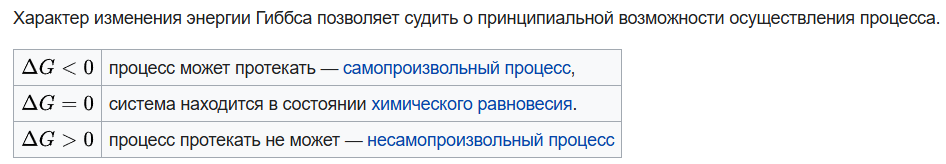

In [10]:
df['ddG_target'] = np.sign(df['ddG']).map({-1: 'Negative', 0 & 1: 'Positive'})

In [11]:
df['ddG_target'].unique()

array([nan, 'Negative', 'Positive'], dtype=object)

In [12]:
df = df.dropna(subset=['ddG_target'])

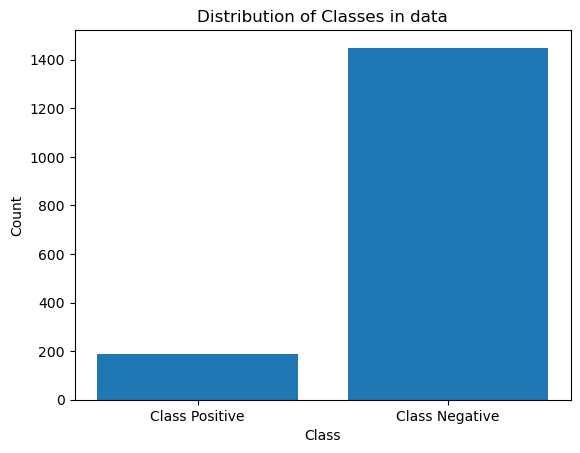

In [13]:
y = df['ddG_target']
count_pos = (y == 'Positive').sum()
count_neg = (y == 'Negative').sum()

plt.bar([0, 1], [count_pos, count_neg])
plt.xticks([0, 1], ['Class Positive', 'Class Negative'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Classes in data')
plt.show()

Видим жуткий дисбаланс классов, либо есть ошибка в расчете, либо так и должно быть, пока оставляем как есть.

Разберемся с признаками:  
Из статьи: *Сродство связывания комплексов может зависеть от мутаций в белках, поскольку мутации вносят различные типы эффектов, которые включают уменьшение гидрофобной области, уменьшение электростатических взаимодействий, потерю водородной связи и т. д., которые могут модулировать или даже нарушать связывание с белками-партнерами, что в дальнейшем приводит к дисфункциональности белков в клетке.*

Фичами будут:  
из столбца "Mutation(s)_cleaned" - надо извлчеь позицию мутации (Описывает мутацию в формате A123B, где A — исходная аминокислота, 123 — позиция, B — новая аминокислота);  
из столбца "Mutation(s)_cleaned" - попробую разделить на отдельные признаки исходную аминокислоту и новую аминокислоту 

In [14]:
df['Position'] = df['Mutation(s)_cleaned'].str[1:-1].str.extract(r'(\d+)').astype(float)

In [15]:
df['Original_AA'] = df['Mutation(s)_cleaned'].str[0] # исхожная АК
df['Mutated_AA'] = df['Mutation(s)_cleaned'].str[-1] # новая (после мутации) АК

Также признаки:  
Affinity_mut_parsed, Affinity_wt_parsed  
kon_mut_parsed, kon_wt_parsed  
koff_mut_parsed, koff_wt_parsed
Temperature  
Position  
Original_AA  
Mutated_AA]

In [16]:
data = df[['Affinity_mut_parsed', 'Affinity_wt_parsed', 'kon_mut_parsed','kon_wt_parsed','koff_mut_parsed','Temperature','Position','Original_AA',
          'Mutated_AA','ddG_target']].copy()

In [17]:
data.isna().sum()

Affinity_mut_parsed       0
Affinity_wt_parsed        0
kon_mut_parsed         1095
kon_wt_parsed          1095
koff_mut_parsed        1095
Temperature               0
Position                  0
Original_AA               0
Mutated_AA                0
ddG_target                0
dtype: int64

Много пропущенных значений, их по хорошему надо заменять медианной, но на данный момент (мало времени) я просто удалю (это грубая ошибка, так делать нельзя)

In [18]:
data = data.dropna()
data = data.reset_index(drop=True)

In [19]:
data

,Affinity_mut_parsed,Affinity_wt_parsed,kon_mut_parsed,kon_wt_parsed,koff_mut_parsed,Temperature,Position,Original_AA,Mutated_AA,ddG_target
0,1.200000e-11,1.800000e-11,4200000.0,6500000.0,2.100000e-04,298.0,67.0,M,L,Negative
1,1.360000e-10,1.620000e-10,14000000.0,13000000.0,1.900000e-03,298.0,6.0,T,A,Negative
2,1.560000e-10,1.620000e-10,16000000.0,13000000.0,2.500000e-03,298.0,8.0,Q,A,Negative
3,1.580000e-10,1.620000e-10,12000000.0,13000000.0,1.900000e-03,298.0,12.0,K,S,Negative
4,1.120000e-10,1.620000e-10,7600000.0,13000000.0,8.500000e-04,298.0,13.0,T,D,Negative
...,...,...,...,...,...,...,...,...,...,...
537,2.600000e-13,3.000000e-13,2000000.0,1900000.0,5.000000e-07,298.0,129.0,S,A,Negative
538,1.120000e-05,1.370000e-05,1833.0,2540.0,2.100000e-02,298.0,89.0,R,P,Negative
539,7.340000e-06,1.370000e-05,4400.0,2540.0,3.200000e-02,298.0,95.0,L,P,Negative
540,5.500000e-06,5.500000e-06,3960.0,4000.0,2.170000e-02,298.0,75.0,E,A,Positive


Применим one-hot encoding для аминокислот:

In [20]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(data[['Original_AA']])

one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=encoder.get_feature_names_out(['Original_AA']))

df_encoder = pd.concat([data.drop('Original_AA', axis=1), one_hot_df], axis=1)


In [21]:
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(data[['Mutated_AA']])

one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=encoder.get_feature_names_out(['Mutated_AA']))

df_encoder_mut = pd.concat([data.drop('Mutated_AA', axis=1), one_hot_df], axis=1)


In [22]:
df = pd.concat([df_encoder, df_encoder_mut], axis=1)
df = df.drop(['Mutated_AA', 'Original_AA'], axis=1)

In [23]:
df = df.loc[:, ~df.columns.duplicated()]
#df.info()

In [24]:
display(df)

,Affinity_mut_parsed,Affinity_wt_parsed,kon_mut_parsed,kon_wt_parsed,koff_mut_parsed,Temperature,Position,ddG_target,Original_AA_A,Original_AA_C,...,Mutated_AA_M,Mutated_AA_N,Mutated_AA_P,Mutated_AA_Q,Mutated_AA_R,Mutated_AA_S,Mutated_AA_T,Mutated_AA_V,Mutated_AA_W,Mutated_AA_Y
0,1.200000e-11,1.800000e-11,4200000.0,6500000.0,2.100000e-04,298.0,67.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.360000e-10,1.620000e-10,14000000.0,13000000.0,1.900000e-03,298.0,6.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.560000e-10,1.620000e-10,16000000.0,13000000.0,2.500000e-03,298.0,8.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.580000e-10,1.620000e-10,12000000.0,13000000.0,1.900000e-03,298.0,12.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.120000e-10,1.620000e-10,7600000.0,13000000.0,8.500000e-04,298.0,13.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,2.600000e-13,3.000000e-13,2000000.0,1900000.0,5.000000e-07,298.0,129.0,Negative,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
538,1.120000e-05,1.370000e-05,1833.0,2540.0,2.100000e-02,298.0,89.0,Negative,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
539,7.340000e-06,1.370000e-05,4400.0,2540.0,3.200000e-02,298.0,95.0,Negative,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
540,5.500000e-06,5.500000e-06,3960.0,4000.0,2.170000e-02,298.0,75.0,Positive,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Применим Label Encoding для целевых значений:

In [26]:
from sklearn import preprocessing 
label = preprocessing.LabelEncoder() 
df['ddG_target'] = label.fit_transform(df['ddG_target'])
print(df['ddG_target'].unique())

[0 1]


Изучим корреляцию фичей с целевым признаком:

<Axes: >

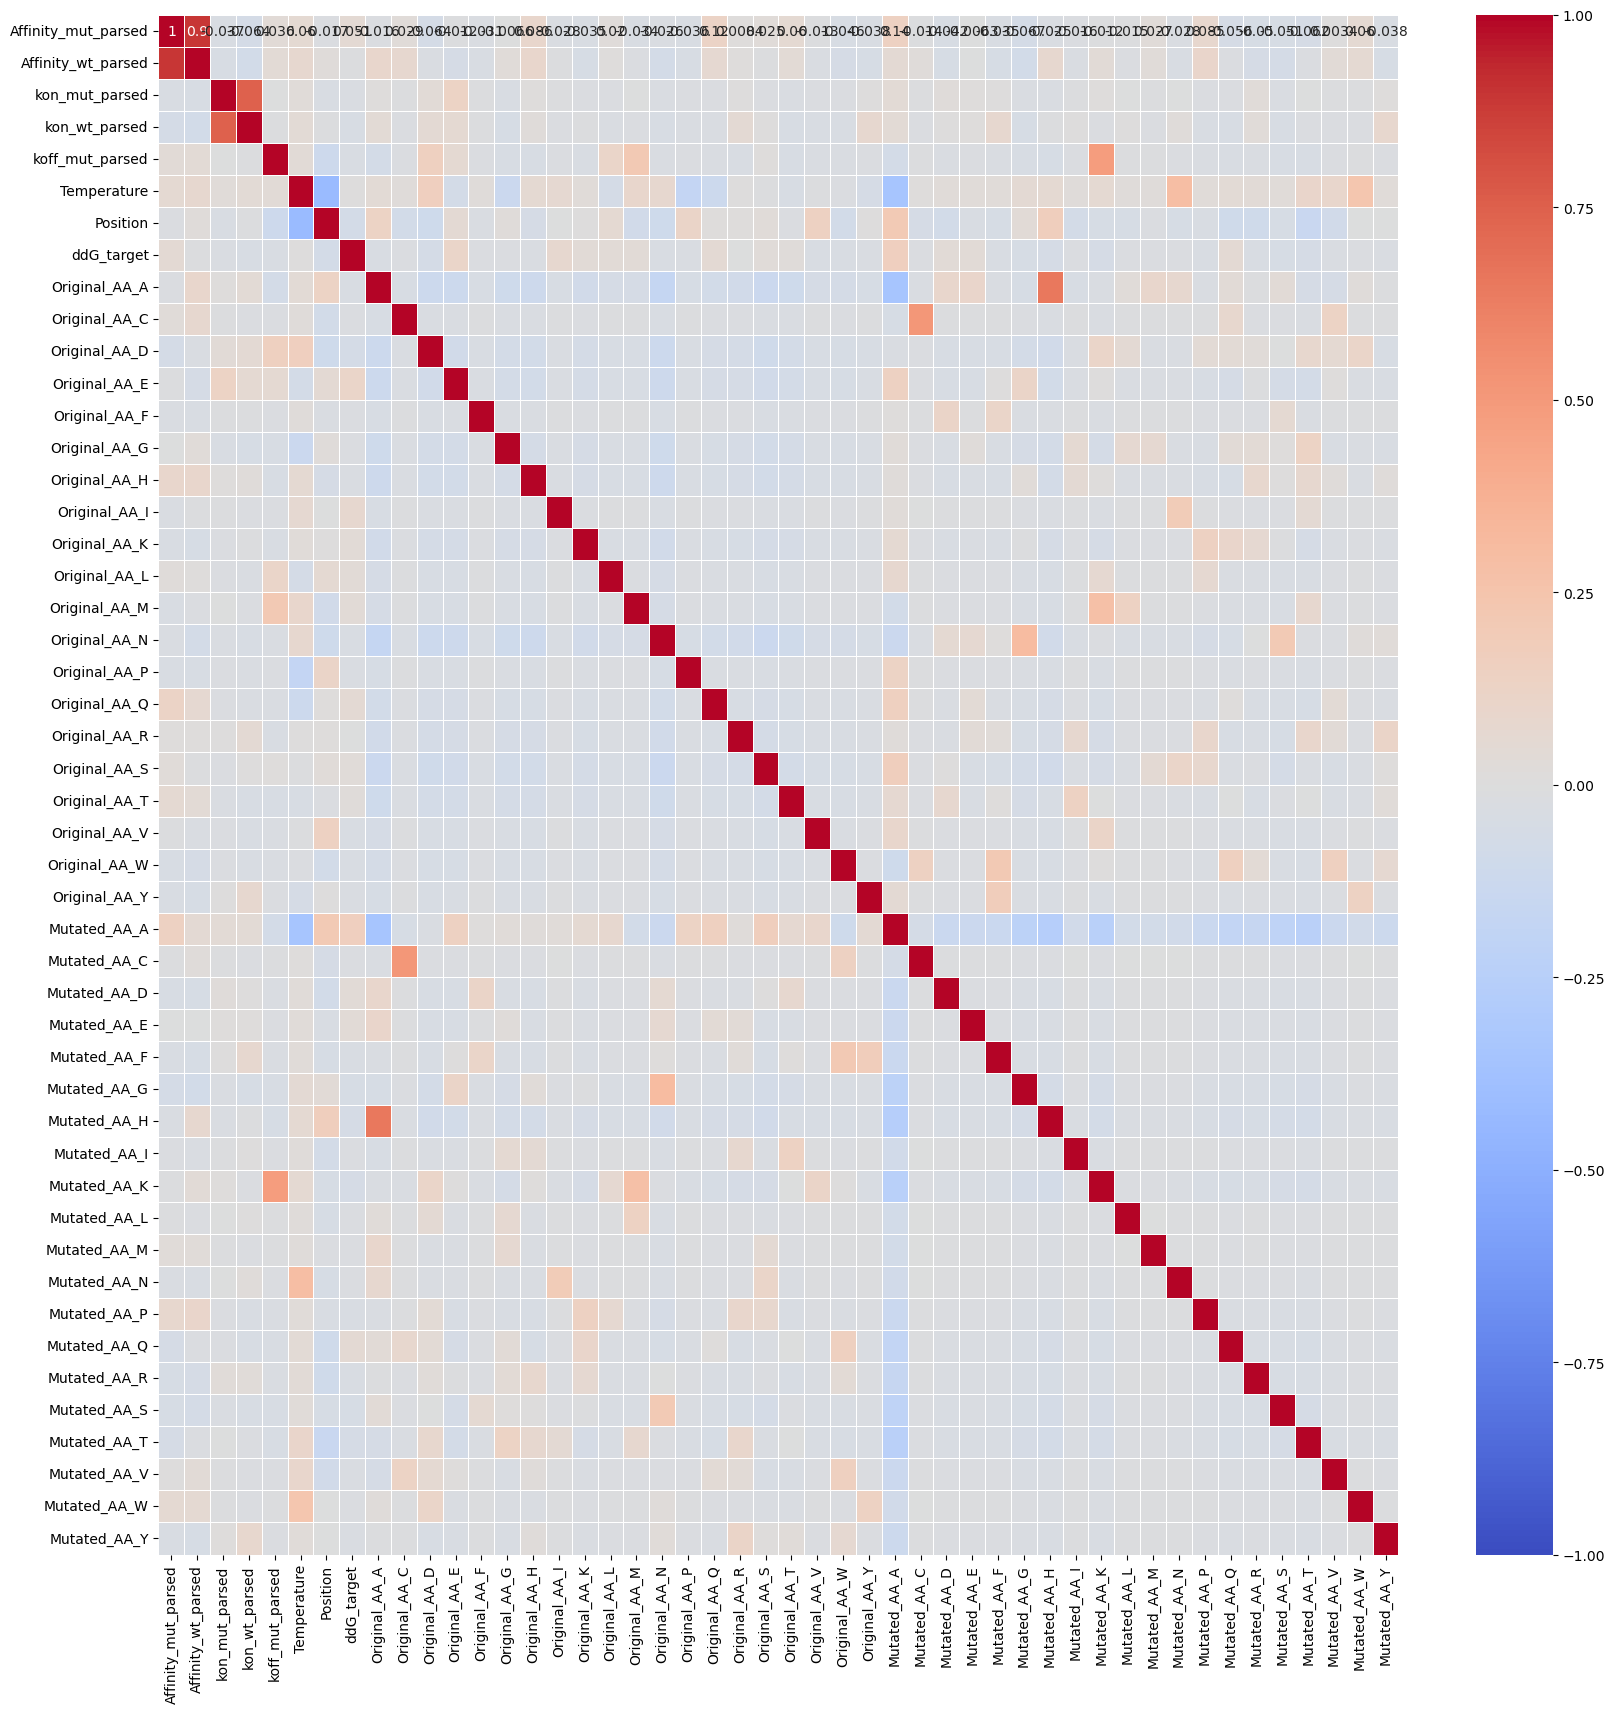

In [29]:
plt.figure(figsize=(20, 20))
corr_mat = df.corr()
sns.heatmap(corr_mat, vmin=-1, vmax=1, cmap='coolwarm', annot= True, linewidths=0.5)

In [30]:
df.corr()

,Affinity_mut_parsed,Affinity_wt_parsed,kon_mut_parsed,kon_wt_parsed,koff_mut_parsed,Temperature,Position,ddG_target,Original_AA_A,Original_AA_C,...,Mutated_AA_M,Mutated_AA_N,Mutated_AA_P,Mutated_AA_Q,Mutated_AA_R,Mutated_AA_S,Mutated_AA_T,Mutated_AA_V,Mutated_AA_W,Mutated_AA_Y
Affinity_mut_parsed,1.000000,0.898352,-0.036970,-0.063534,0.035577,0.060014,-0.017270,0.050952,-0.015787,0.028532,...,0.026999,-0.028221,0.084756,-0.056112,-0.049818,-0.051285,-0.062147,0.003424,0.059733,-0.037994
Affinity_wt_parsed,0.898352,1.000000,-0.045034,-0.079344,0.045822,0.076998,0.016340,-0.010074,0.092040,0.074981,...,0.027181,-0.035563,0.099159,-0.021639,-0.057541,-0.063594,-0.021945,0.033180,0.061744,-0.047970
kon_mut_parsed,-0.036970,-0.045034,1.000000,0.746947,-0.000401,0.026651,-0.036842,-0.024929,0.010166,-0.012527,...,-0.011199,-0.005341,-0.019135,-0.023264,0.026157,-0.026257,-0.006768,-0.014336,-0.012295,0.008731
kon_wt_parsed,-0.063534,-0.079344,0.746947,1.000000,-0.012145,0.045222,-0.011888,-0.040168,0.043524,-0.021461,...,-0.019199,0.016792,-0.032525,-0.039669,0.025315,-0.040092,-0.022506,-0.017440,-0.020801,0.078233
koff_mut_parsed,0.035577,0.045822,-0.000401,-0.012145,1.000000,0.036811,-0.117111,-0.036009,-0.070934,-0.016555,...,-0.013763,-0.017312,-0.024826,-0.034941,-0.031053,-0.039966,-0.045159,-0.023078,-0.015358,-0.023308
Temperature,0.060014,0.076998,0.026651,0.045222,0.036811,1.000000,-0.427369,0.001902,0.046136,0.019797,...,0.017691,0.292597,0.030872,0.040159,0.035783,0.025714,0.096101,0.092730,0.238037,0.026660
Position,-0.017270,0.016340,-0.036842,-0.011888,-0.117111,-0.427369,1.000000,-0.075011,0.129882,-0.079955,...,-0.016971,-0.050301,-0.035040,-0.101307,-0.098885,-0.049267,-0.144850,-0.087014,-0.007403,-0.004843
ddG_target,0.050952,-0.010074,-0.024929,-0.040168,-0.036009,0.001902,-0.075011,1.000000,-0.036212,-0.020770,...,-0.018560,-0.020770,-0.032389,0.053017,-0.037541,-0.048317,-0.055686,-0.029511,-0.020770,-0.027970
Original_AA_A,-0.015787,0.092040,0.010166,0.043524,-0.070934,0.046136,0.129882,-0.036212,1.000000,-0.039266,...,0.088403,0.071291,-0.025314,0.032482,-0.008526,0.032304,-0.061685,-0.055791,0.016012,-0.011522
Original_AA_C,0.028532,0.074981,-0.012527,-0.021461,-0.016555,0.019797,-0.079955,-0.020770,-0.039266,1.000000,...,-0.008320,-0.009311,-0.014519,0.083483,-0.016829,-0.021660,-0.024963,0.130178,-0.009311,-0.012539


## Обучение модели

Разделим выборки на обучающую, вадидационую и тестовую:

In [31]:
from sklearn.model_selection import train_test_split
X = df.drop('ddG_target', axis=1)
y = df['ddG_target']


X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(y_test.shape)

(325, 47)
(108, 47)
(109, 47)
(108,)


Скорее всего надо было сделать еще шкалирование признаков, но я не успеваю, поздно заметила информацию про стажировку.

У нас выходит обычная бинарная классификация.  
Логистическая регрресия: (помним про дисбаланс классов, для этого есть class_weight='balanced' и balanced_accuracy_score)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
predictions_test = model.predict(X_val)
print('Balanced accuracy', balanced_accuracy_score(y_val, predictions_test))

Balanced accuracy 0.6981792717086834


Качество модели не очень, но я в целом знаю как ее улучшить, а также есть другие архитектуры которые явно справятся лучше

Что надо сделать в дальнейшем:  
- обязательно сделать стандартизацию данных до разделения на выборки  
- попробовать разные модели (на валидационной выборке выбрать лучшую и проверить на тестовой выборке)
- не удалять пропущенные значения, а заполнить их (пропусков оказалось слишком много - просто удаление их сказывается на обучении)